# Exercise 10-1: Create a linear regression

## Get the data

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

data_dir = "../../data"

In [2]:
awards_df = pd.read_pickle(f"{data_dir}/pkl_files/awards_data_2010_2025.pkl")

## Prepare the data

In [3]:
# Switch awd_eff_date to datetime
awards_df['awd_eff_date'] = pd.to_datetime(awards_df['awd_eff_date'], format='%Y-%m-%d')

In [4]:
# Add a column for the year
awards_df['awd_year'] = awards_df['awd_eff_date'].dt.year
# Add a column for string representation of year and month
awards_df['awd_yearmonth'] = awards_df['awd_eff_date'].dt.to_period('M').astype(str)
# Add a column for monthnumber
awards_df['awd_monthnumber'] = awards_df['awd_eff_date'].dt.month
# Add a column for month
awards_df['awd_month'] = awards_df['awd_eff_date'].dt.month_name()
# Add a column for day of month
awards_df['awd_day'] = awards_df['awd_eff_date'].dt.day
# Add a column for day of year
awards_df['awd_dayofyear'] = awards_df['awd_eff_date'].dt.dayofyear
# Add an awd_count column
awards_df['awd_count'] = 1

In [5]:
# Define sort order for months
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
# Convert awd_month to a categorical type with the defined order
awards_df['awd_month'] = pd.Categorical(awards_df['awd_month'], categories=month_order, ordered=True)

In [6]:
# Pivot: award_count by year, indexed by day
awards_pivot_day_yr_df = awards_df.pivot_table(index='awd_dayofyear', columns='awd_year', values='awd_count', aggfunc='sum', fill_value=0)

In [7]:
# Pivot: award_count by month, indexed by year
awards_pivot_month_yr_df = awards_df.pivot_table(index='awd_month', columns='awd_year', values='awd_count', aggfunc='sum', fill_value=0)

In [8]:
# Pivot: awd_amount by dir_abbr, indexed by year
awards_pivot_dir_yrmth_df = awards_df.pivot_table(index='awd_yearmonth', columns='dir_abbr', values='awd_amount', aggfunc='sum', fill_value=0)

In [9]:
# Summarize awd_count and awd_amount by year, monthnumber, and dayofyear
awards_ymd_summary_df = awards_df.groupby(['awd_year', 'awd_monthnumber', 'awd_dayofyear']).agg({'awd_count': 'sum', 'awd_amount': 'sum'}).reset_index()

<Axes: title={'center': 'Award Count by Day & Year'}, xlabel='awd_dayofyear'>

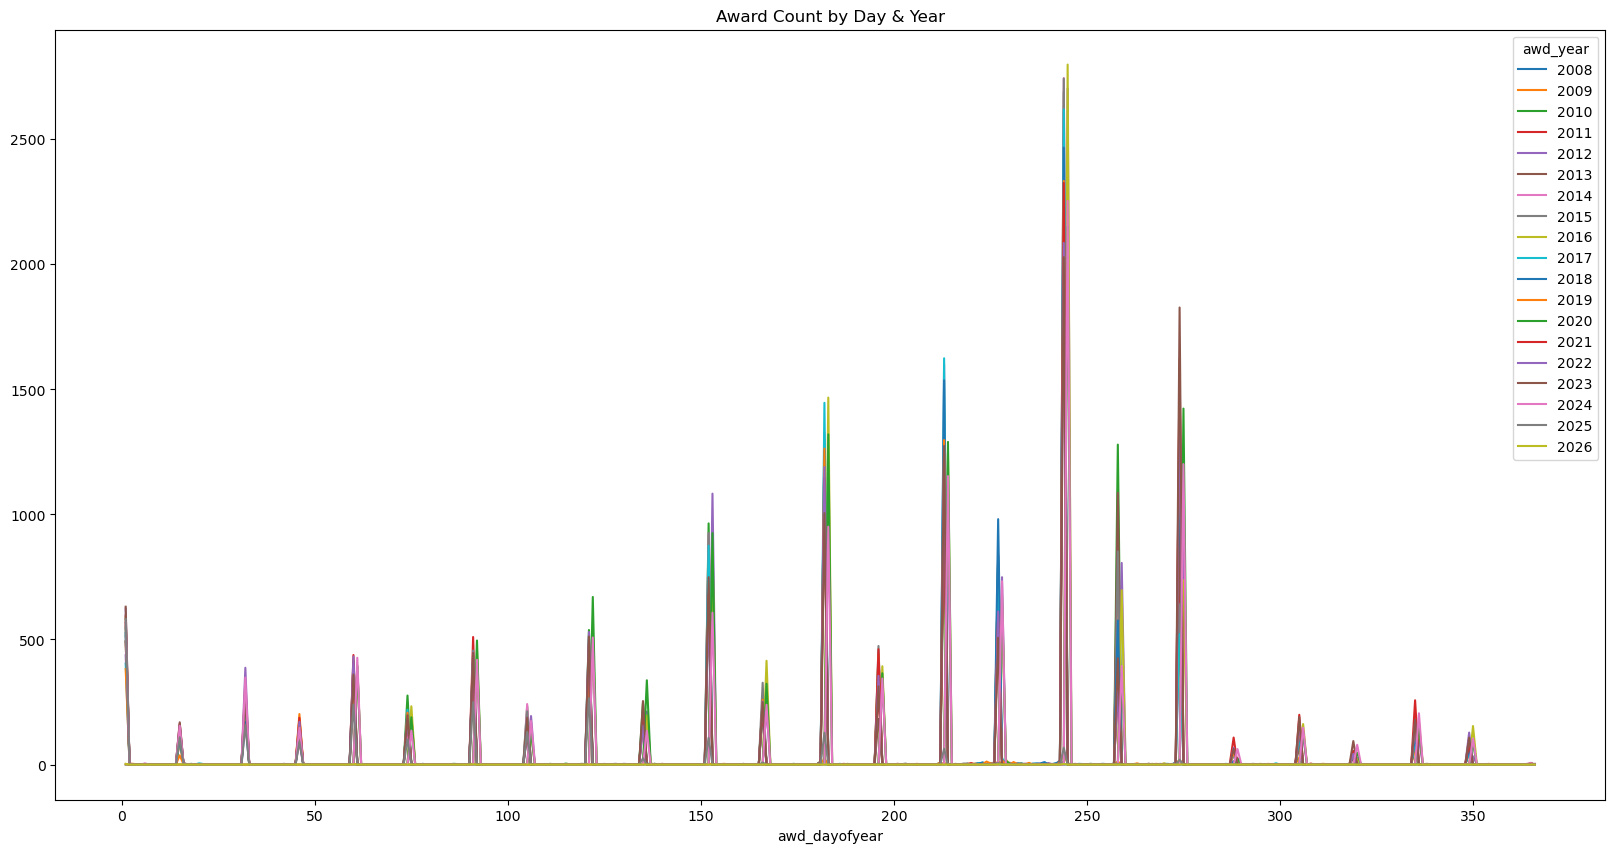

In [10]:
# Plot the awards_pivot_day_yr_df pivot table
awards_pivot_day_yr_df.plot(title='Award Count by Day & Year', figsize=(20, 10), legend=True)

<Axes: title={'center': 'Award Count by Month & Year'}, xlabel='awd_month'>

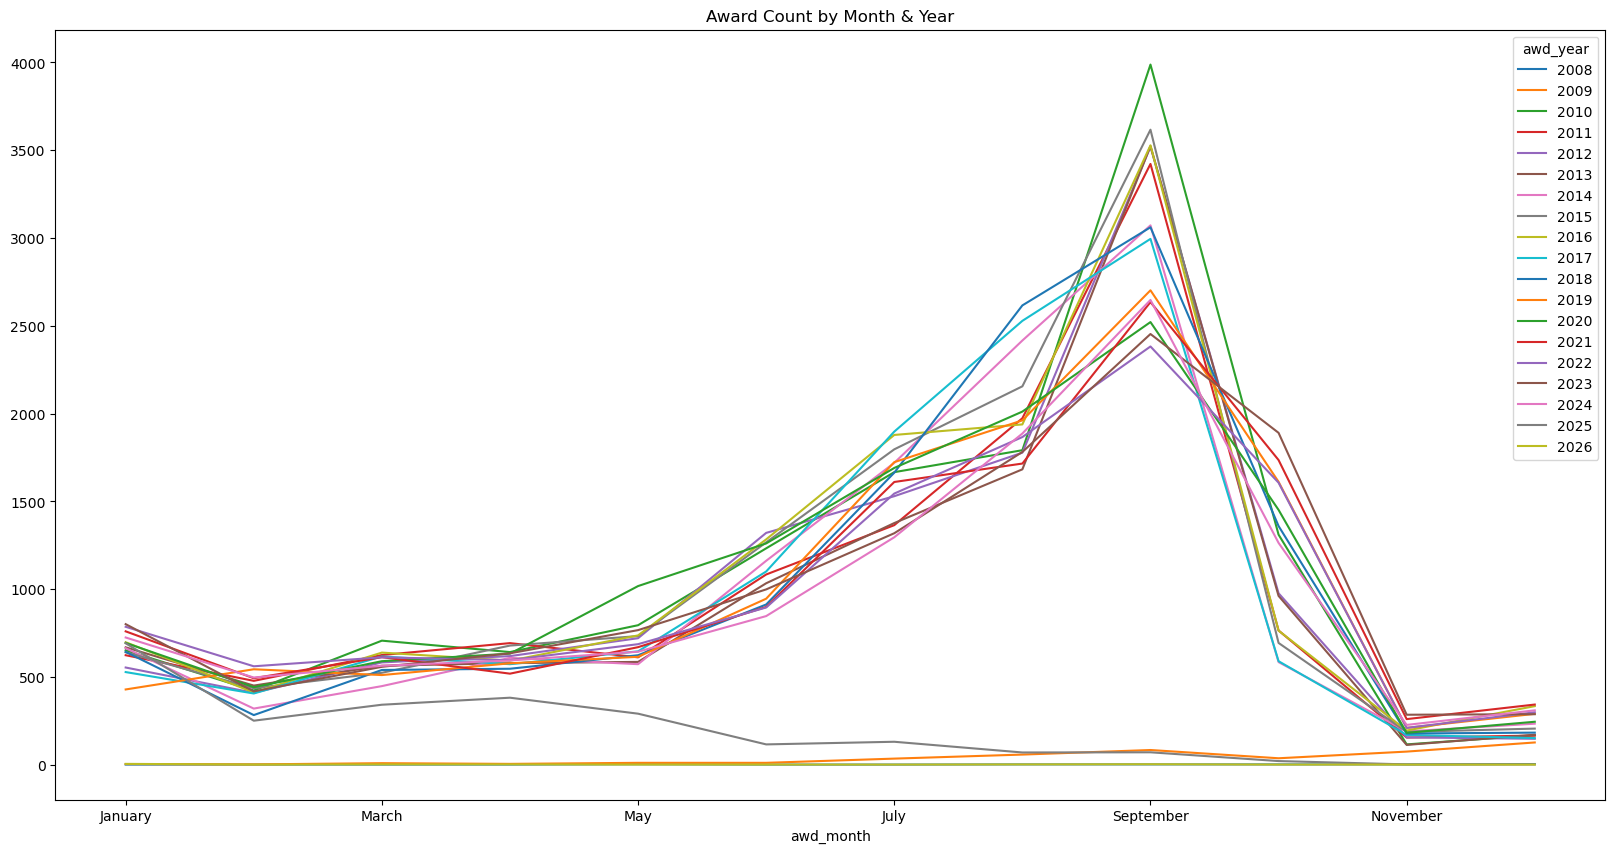

In [11]:
# Plot the awards_pivot_month_yr_df pivot table
awards_pivot_month_yr_df.plot(title='Award Count by Month & Year', figsize=(20, 10), legend=True)

<Axes: xlabel='awd_year', ylabel='awd_month'>

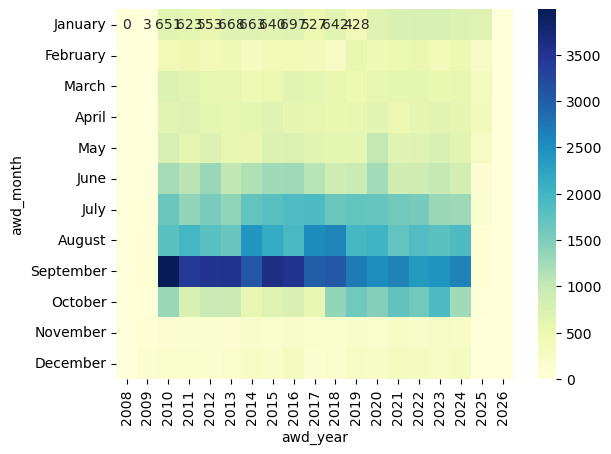

In [12]:
# heatmap of awards_pivot_month_yr_df
sns.heatmap(awards_pivot_month_yr_df, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

<Axes: title={'center': 'Award Amount by Directorate & Month'}, xlabel='awd_yearmonth'>

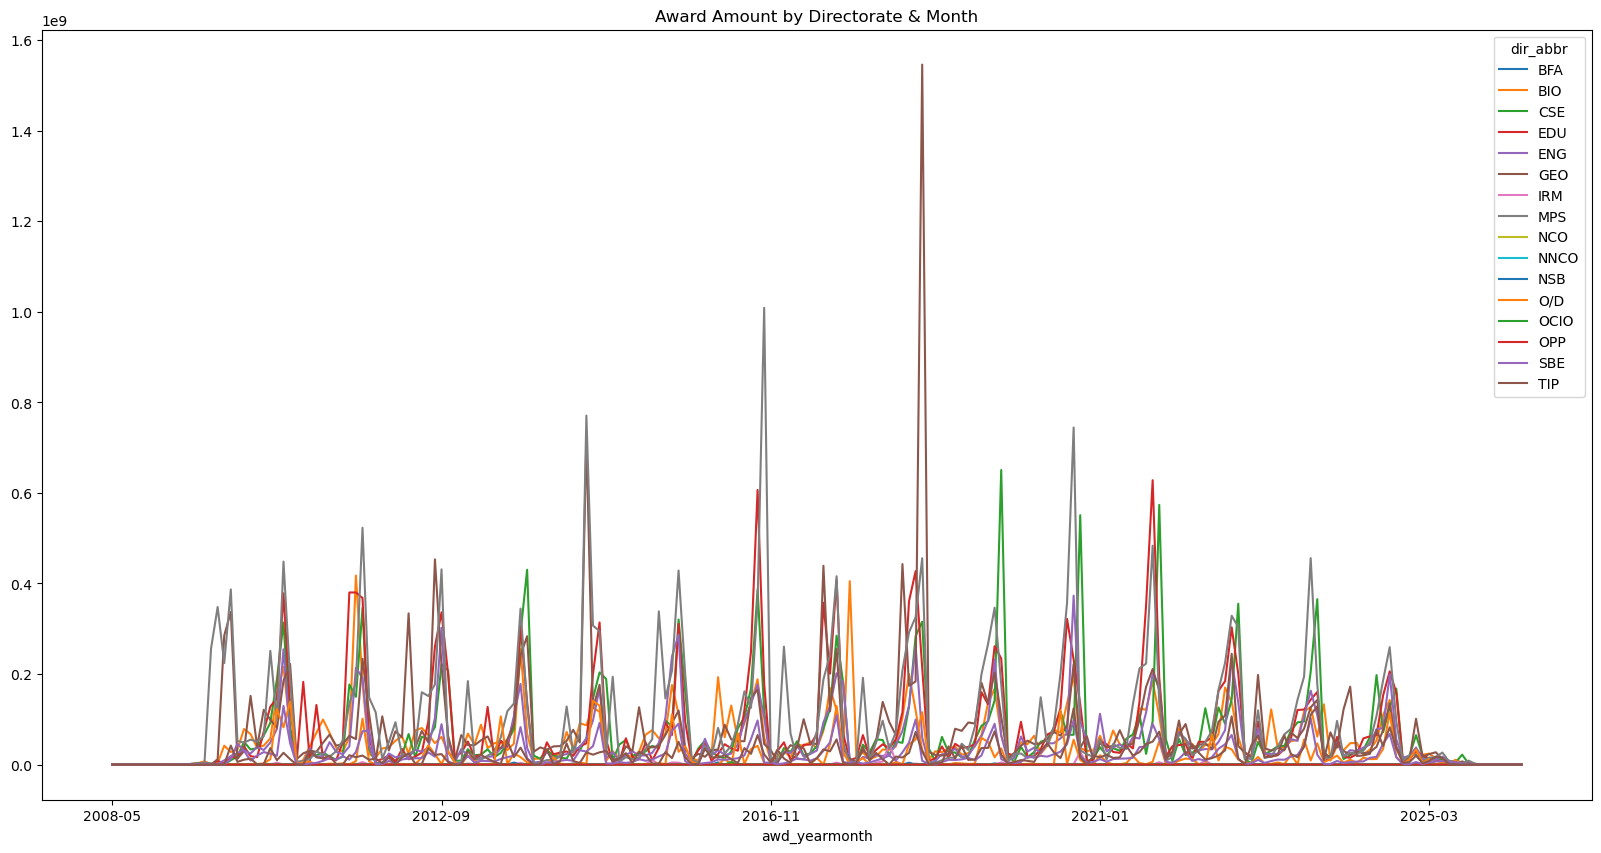

In [13]:
# Plot the awards_pivot_dir_yrmth_df pivot table
awards_pivot_dir_yrmth_df.plot(title='Award Amount by Directorate & Month', figsize=(20, 10), legend=True)

## Identify a correlation

In [14]:
# Calculate the pairwise correlation of columns in the DataFrame.
# The corr() method computes the Pearson correlation coefficient, which measures the linear relationship between columns.
# A value close to 1 indicates a strong positive correlation, -1 indicates a strong negative correlation, and 0 indicates no correlation.
awards_pivot_month_yr_df.corr()

awd_year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
awd_year,,,,,,,,,,,,,,,,,,,
2008,1.000000,0.736942,-0.073397,-0.096057,-0.092226,-0.083268,-0.089601,-0.090601,-0.083898,-0.112237,-0.044199,-0.059935,-0.078794,-0.061118,-0.096585,-0.045409,-0.050828,-0.471611,-0.290565
2009,0.736942,1.000000,0.207611,0.211579,0.199851,0.220827,0.234112,0.220601,0.233881,0.201000,0.239350,0.223020,0.114071,0.205411,0.153242,0.161060,0.222761,-0.686150,-0.163358
2010,-0.073397,0.207611,1.000000,0.980358,0.993608,0.995263,0.927841,0.971426,0.977283,0.912609,0.929077,0.937793,0.931343,0.941505,0.923348,0.909655,0.965006,-0.250032,0.256564
2011,-0.096057,0.211579,0.980358,1.000000,0.990050,0.991818,0.970392,0.991880,0.985595,0.956542,0.945991,0.918297,0.918755,0.902361,0.902820,0.869787,0.965998,-0.219476,0.299031
2012,-0.092226,0.199851,0.993608,0.990050,1.000000,0.993749,0.954011,0.987881,0.989124,0.939262,0.934980,0.931566,0.936863,0.921837,0.911728,0.890213,0.960893,-0.260819,0.238678
2013,-0.083268,0.220827,0.995263,0.991818,0.993749,1.000000,0.944180,0.981165,0.982671,0.925885,0.932665,0.925857,0.917753,0.925786,0.913029,0.891201,0.967126,-0.222889,0.304692
2014,-0.089601,0.234112,0.927841,0.970392,0.954011,0.944180,1.000000,0.984843,0.974299,0.993932,0.964613,0.915990,0.932343,0.882344,0.901500,0.846533,0.950467,-0.247040,0.264245
2015,-0.090601,0.220601,0.971426,0.991880,0.987881,0.981165,0.984843,1.000000,0.996158,0.974338,0.946424,0.920982,0.930764,0.897899,0.899846,0.855995,0.955749,-0.241546,0.257797
2016,-0.083898,0.233881,0.977283,0.985595,0.989124,0.982671,0.974299,0.996158,1.000000,0.963843,0.936266,0.920605,0.928594,0.905420,0.899474,0.855818,0.949940,-0.244180,0.256468


<Axes: xlabel='awd_year', ylabel='awd_year'>

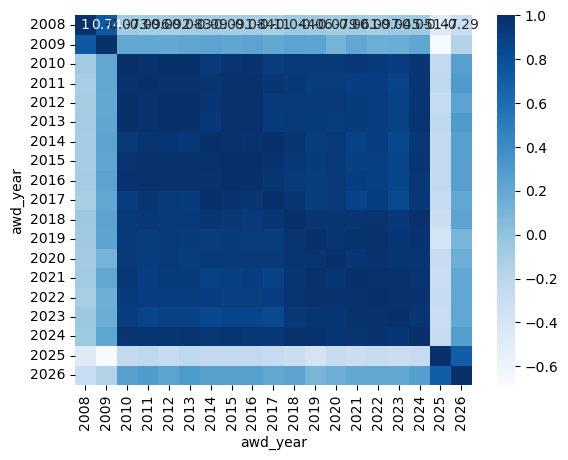

In [15]:
# Plot a heatmap to visualize the correlation matrix of awards_pivot_month_yr_df
sns.heatmap(awards_pivot_month_yr_df.corr(), annot=True, cmap='Blues')

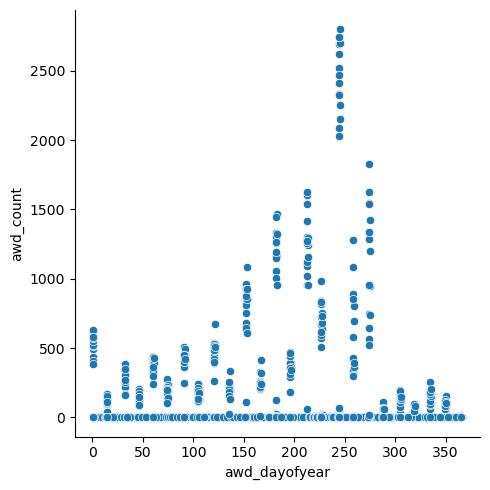

In [16]:
# Create a scatter plot to visualize the relationship between the day of the year and the award count
sns.relplot(data=awards_ymd_summary_df, x='awd_dayofyear', y='awd_count')

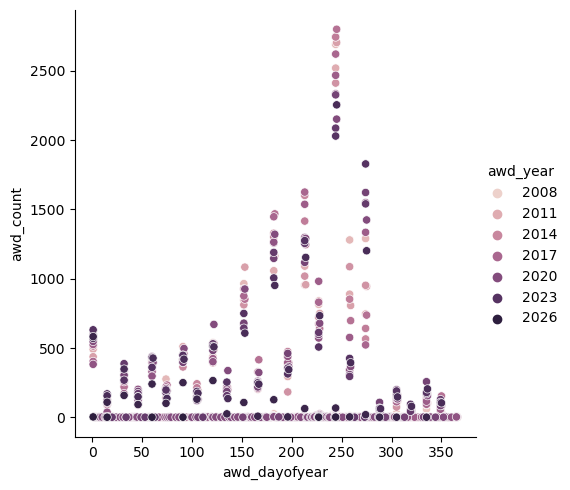

In [17]:
# Same scatter plot with hue for year
sns.relplot(data=awards_ymd_summary_df, x='awd_dayofyear', y='awd_count', hue='awd_year')

<Axes: xlabel='dir_abbr', ylabel='dir_abbr'>

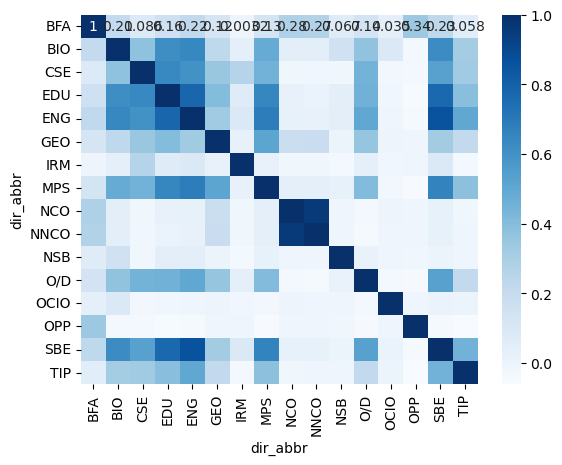

In [18]:
# How strongly do directorates' monthly award amounts correlate with each other?
# Make a heatmap of the correlation matrix of awards_pivot_dir_yrmth_df
awards_pivot_dir_yrmth_df.corr()
sns.heatmap(awards_pivot_dir_yrmth_df.corr(), annot=True, cmap='Blues')

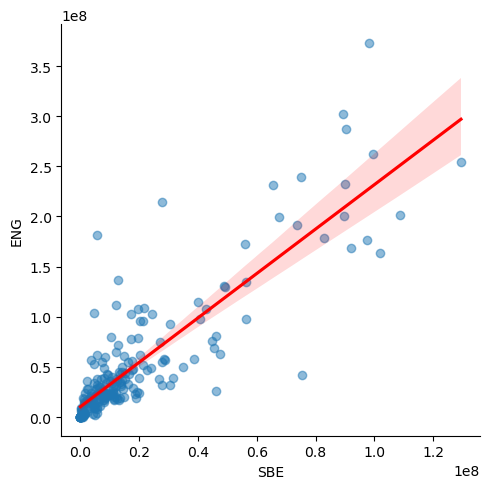

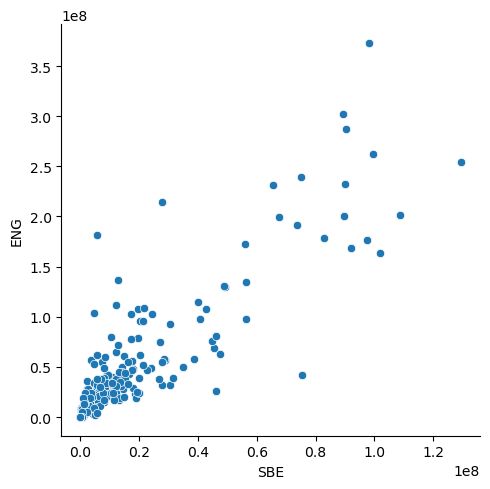

In [33]:
# What does the relationship between SBE and ENG look like?
# Create a scatter plot to visualize the relationship between SBE and ENG
# Add a linear regression line to the scatter plot
sns.lmplot(data=awards_pivot_dir_yrmth_df, 
           x='SBE', y='ENG', 
           line_kws={'color': 'red'}, 
           scatter_kws={'alpha': 0.5})  
sns.relplot(data=awards_pivot_dir_yrmth_df, 
            x='SBE', y='ENG')

## Create a linear model

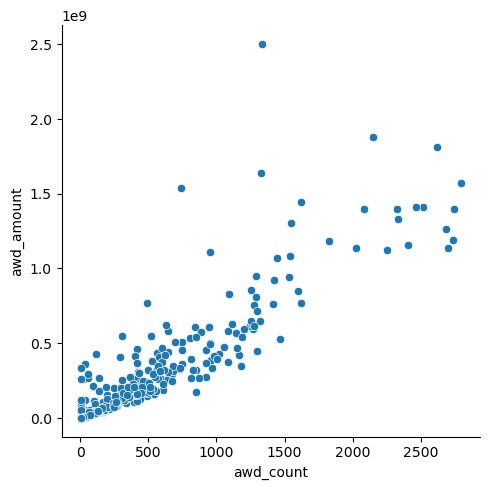

In [20]:
# Plot the relationship between the number of awards and the amount of awards
# in the awards_ymd_summary_df DataFrame
sns.relplot(data=awards_ymd_summary_df, 
            x='awd_count', y='awd_amount')

In [21]:
# Is awd_count predictive of awd_amount?
# Create a linear regression model to predict the amount of awards based on the number of awards
# Begin by splitting the data into training and testing sets using the train_test_split function from sklearn
x_train, x_test, y_train, y_test = train_test_split(
    awards_ymd_summary_df[['awd_count']], awards_ymd_summary_df[['awd_amount']])

In [22]:
# Create a linear regression model using the LinearRegression class from sklearn
# and fit the model to the training data
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [23]:
# Check the fit of the model
# The score() method returns the coefficient of determination (R^2) of the prediction.
# It measures how well the model predicts the target variable, with 1 being a perfect prediction
# and 0 indicating no predictive power.
model.score(x_test, y_test)

0.8247678886984385

In [24]:
# Using the trained model, make predictions on the test data
# The predict() method returns the predicted values for the target variable based on the input features.
y_predicted = model.predict(x_test)
predicted = pd.DataFrame(y_predicted, columns = ['awd_amount_predicted'])

## Plot the regression line

In [25]:
# Use the join() method to combine the predicted values with the original test data
# The join() method is used to combine two DataFrames based on their indices.
final = predicted.join([x_test.reset_index(drop=True),
                        y_test.reset_index(drop=True)])
final.head()

,awd_amount_predicted,awd_count,awd_amount
0,-1.136986e+06,1,2132920.0
1,2.247780e+08,396,157844041.0
2,-1.136986e+06,1,76405.0
3,-1.136986e+06,1,19593.0
4,6.887858e+03,3,1058883.0


In [26]:
# rename the awd_amount column to indicate that it stores actual values, not predicted values
final.rename(columns={'awd_amount':'awd_amount_actual'}, inplace=True)
final.head()

,awd_amount_predicted,awd_count,awd_amount_actual
0,-1.136986e+06,1,2132920.0
1,2.247780e+08,396,157844041.0
2,-1.136986e+06,1,76405.0
3,-1.136986e+06,1,19593.0
4,6.887858e+03,3,1058883.0


In [27]:
# Melt the DataFrame to combine the actual and predicted values into a long format
# The melt() function is used to reshape the DataFrame from wide format to long format.
finalMelt = pd.melt(final, id_vars=['awd_count'], 
                    value_vars=['awd_amount_actual','awd_amount_predicted'], 
                    var_name='Variable', value_name='Value')
finalMelt.head()

,awd_count,Variable,Value
0,1,awd_amount_actual,2132920.0
1,396,awd_amount_actual,157844041.0
2,1,awd_amount_actual,76405.0
3,1,awd_amount_actual,19593.0
4,3,awd_amount_actual,1058883.0


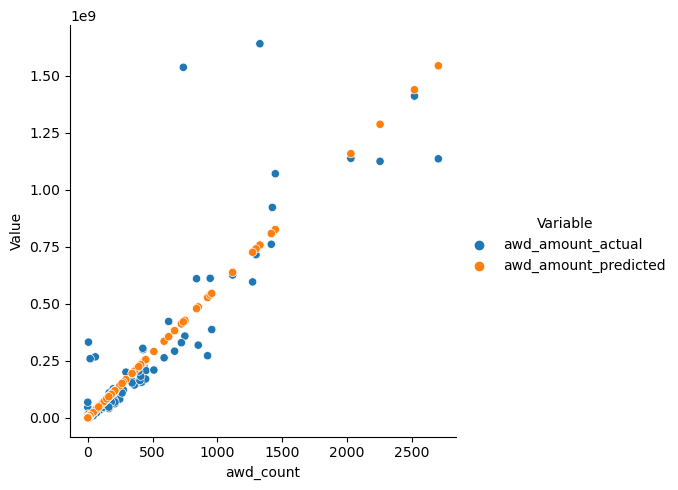

In [28]:
# Make a scatter plot to visualize the relationship between the number of awards and the amount of awards
# in the melted DataFrame, using the Variable column to differentiate between actual and predicted values
# in the legend
sns.relplot(data=finalMelt, x='awd_count', y='Value', hue='Variable')

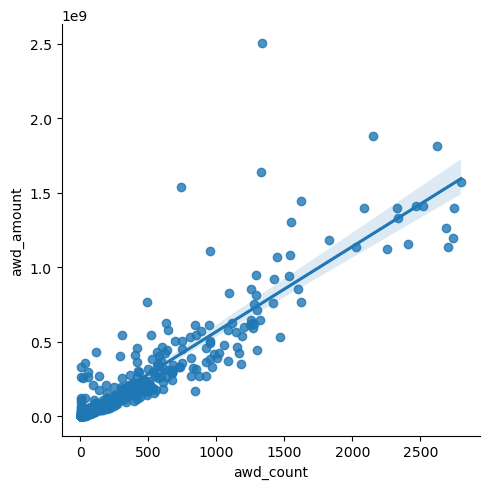

In [29]:
# Make a seaborn lmplot to visualize the relationship between the number of awards and the amount of awards
# in the awards_ymd_summary_df DataFrame, using a linear regression line to show the trend
sns.lmplot(data=awards_ymd_summary_df, x='awd_count', y='awd_amount')

## Plot the residuals

In [30]:
# Add a column for the residuals, which is the difference between the actual and predicted values
# The residuals represent the error in the model's predictions.
final['Residuals'] = final.awd_amount_actual - final.awd_amount_predicted

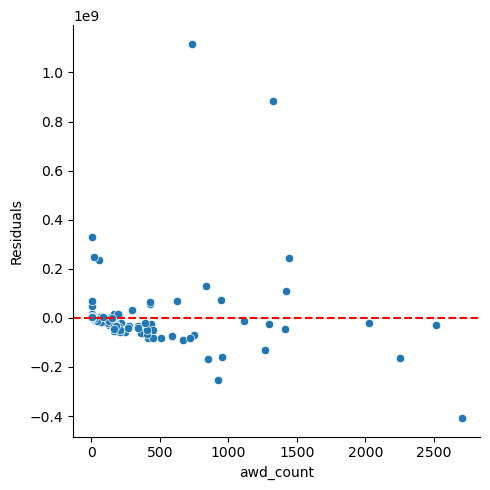

In [31]:
# Plot the residuals against the number of awards
# The residuals should be randomly distributed around zero if the model is a good fit.
g = sns.relplot(data=final, x='awd_count', y='Residuals')
for ax in g.axes.flat:
    ax.axhline(0, ls='--', color='red')

<Axes: xlabel='awd_count', ylabel='awd_amount'>

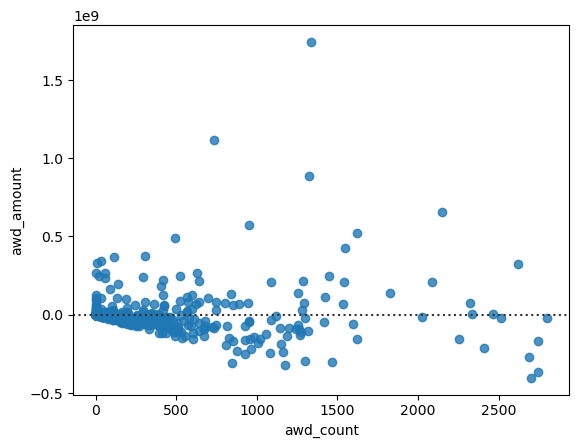

In [32]:
# Make a seaborn residplot to visualize the residuals of the linear regression model
# The residplot() function is used to visualize the residuals of a linear regression model.
sns.residplot(data=awards_ymd_summary_df, x='awd_count', y='awd_amount')

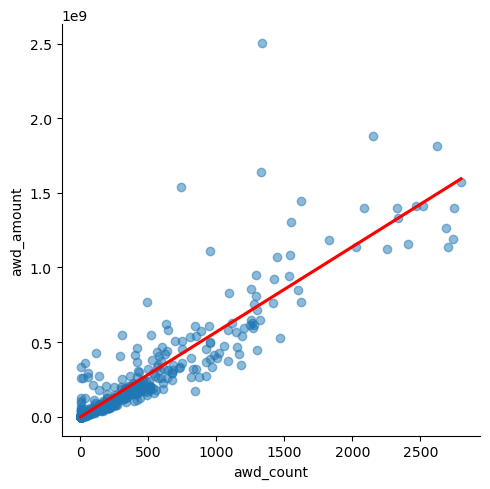

In [35]:
sns.lmplot(data=awards_ymd_summary_df, x='awd_count', y='awd_amount', ci=None, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

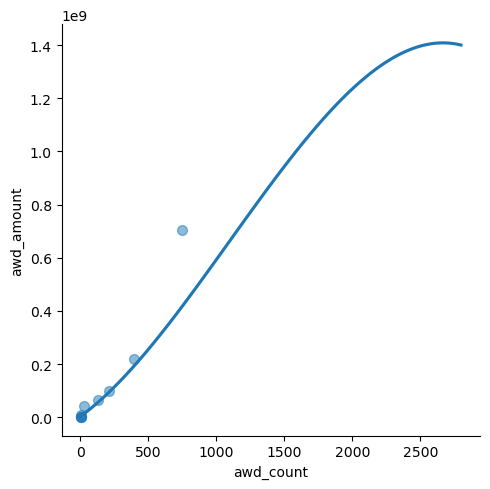

In [40]:
sns.lmplot(data=awards_ymd_summary_df, x='awd_count', y='awd_amount', ci=None,markers='o', scatter_kws={'alpha': 0.5}, x_bins=20, order=3)

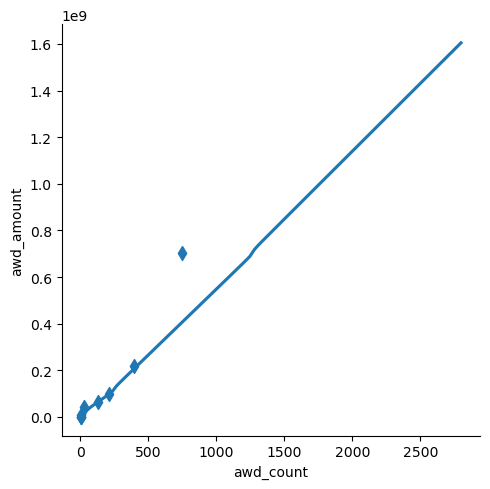

In [41]:
sns.lmplot(data=awards_ymd_summary_df, x='awd_count', y='awd_amount', ci=None,markers='d', x_bins=20, lowess=True)